# Uniswap v3 Impermanent Loss and Swap fees (live-data Experiments)

In [1]:
from datetime import datetime, UTC
import json
from requests import post
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from decimal import Decimal, getcontext

from datetime import datetime
from dateutil.relativedelta import relativedelta

from ipywidgets import IntProgress
from IPython.display import display

### Setup

In [132]:
rng = np.random.default_rng()

In [2]:
# retrieve API keys from environment
api_keys = dict()
with open(".env") as f:
    for line in f.readlines():
        elems = line.split("=")
        api_keys[elems[0].strip()] = elems[1].strip()
api_keys

{'SUBGRAPH_API_KEY': '57a4c82d1adf368ab1ba1492473a2338'}

In [3]:
# environmental variables for calculations
getcontext().prec = 50
delta_pi = 10
beta_p = Decimal(1.0001)
WETH_dec = 18
USDC_dec = 6
Q128 = Decimal(2) ** 128

In [4]:
def send_graphql_query_to_subgraph(api_key, 
                                   query, 
                                   subgraph_url="https://gateway.thegraph.com/api/subgraphs/id",
                                   url_ext="5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV",
                                   variables = None):
  headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
  }

  # Prepare the request payload
  payload = {'query': query}
  if variables:
      payload['variables'] = variables
  
  # Send the GraphQL request to the Subgraph
  response = post(f"{subgraph_url}/{url_ext}", headers=headers, json=payload)

  # Check if the request was successful
  if response.status_code == 200:
      return response.json()
  else:
      print("Error:", response.text)
      return None

In [5]:
def tick_to_sqrt_price(tau : int) -> float:
    return float(1/((beta_p**Decimal(tau)) / Decimal(10**(WETH_dec-USDC_dec))))

### Pool Statistics

In [6]:
lookback_period = relativedelta(days=36)
END_DATE = datetime.today().strftime("%Y-%m-%d")
START_DATE = (datetime.today() - lookback_period).strftime("%Y-%m-%d")

In [7]:
start_dt = datetime.strptime(START_DATE, "%Y-%m-%d").replace(tzinfo=UTC)
print(int(start_dt.timestamp()))

1769558400


In [351]:
START_DATE

'2026-01-28'

In [8]:
WETH_USDC_pool_addr="0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640"
N=lookback_period.days + 1

In [35]:
raw_data_pool = send_graphql_query_to_subgraph(api_keys['SUBGRAPH_API_KEY'], f"""{{
  poolDayDatas(
    first: {N}, 
    orderBy: date, 
    where: {{
      pool: "{WETH_USDC_pool_addr}", 
      date_gt: {int(start_dt.timestamp())}
    }}
  ) {{
    date
    liquidity
    tick
    feeGrowthGlobal0X128
    feeGrowthGlobal1X128
    feesUSD
    volumeToken0
    volumeToken1
    token0Price
    token1Price
    sqrtPrice
  }}
}}
""")


In [36]:
rows = []
for ele in raw_data_pool["data"]["poolDayDatas"]:
    rows.append({
        'date': datetime.fromtimestamp(ele['date'], UTC),  
        'tick': float(ele['tick']),                        # current tick at end of period
        'active_liq': float(ele['liquidity']),             # in range liquidity at end of period
        'feeGrowthGlobal0X128': float(ele['feeGrowthGlobal0X128']),  # globally-accumulated fees in pool 
        'feeGrowthGlobal1X128': float(ele['feeGrowthGlobal1X128']),
        'fees_USD': float(ele['feesUSD']),
        'volumeToken0': float(ele['volumeToken0']),
        'volumeToken1': float(ele['volumeToken1']),
        'token0Price': float(ele['token0Price']),
        'token1Price': float(ele['token1Price']),
    })
pool_data_df = pd.DataFrame(rows)

In [37]:
pool_data_df = pool_data_df.set_index('date')
pool_data_df['price'] = 1/((beta_p**pool_data_df['tick'].apply(Decimal)) / Decimal(10**(WETH_dec-USDC_dec)))
pool_data_df['sqrt_price']=np.sqrt(pool_data_df['price'])

In [38]:
# convert fees from Q128 format to denominated in respective token 
pool_data_df['feeGrowthGlobal0'] = pool_data_df['feeGrowthGlobal0X128'].astype("str").apply(Decimal) / (Q128*(10**USDC_dec))
pool_data_df['feeGrowthGlobal1'] = pool_data_df['feeGrowthGlobal1X128'].astype("str").apply(Decimal) / (Q128*(10**WETH_dec))

In [61]:
pool_data_df['dfeeGrowthGlobal1X128'] = (pool_data_df['feeGrowthGlobal1X128'].shift(-1) - pool_data_df['feeGrowthGlobal1X128']).dropna()
pool_data_df['dfeeGrowthGlobal0X128'] = (pool_data_df['feeGrowthGlobal0X128'].shift(-1) - pool_data_df['feeGrowthGlobal0X128']).dropna()

In [70]:
pool_data_df['feesToken1'] = pool_data_df['fees_USD'] / pool_data_df['token1Price']
pool_data_df['tmp'] = pool_data_df['feeGrowthGlobal0X128'] - 

### Calculate $\Delta L,\,\Phi_R^\mathcal{X},\,\Phi_R^\mathcal{Y}$ 

In [13]:
# range of ticks seen during date range chosen
tick_range = np.arange(np.round(pool_data_df['tick'].min(), decimals=-1), np.round(pool_data_df['tick'].max(), decimals=-1), delta_pi).astype(int)

In [99]:
raw_data_ticks = send_graphql_query_to_subgraph(api_keys['SUBGRAPH_API_KEY'], f"""
    {{
      pool(id:"{WETH_USDC_pool_addr}") {{
        tick
        feeTier
        liquidity
        feeGrowthGlobal0X128
        feeGrowthGlobal1X128
        token0Price
      }}
      ticks(first: {tick_range.shape[0]+1}, where: {{ pool: "{WETH_USDC_pool_addr}", tickIdx_in: {tick_range}}}) 
      {{
        tickIdx
        feeGrowthOutside0X128
        feeGrowthOutside1X128
        liquidityNet
        price0
        price1
      }}
    }}
    """)

In [335]:
rows = []
for ele in raw_data_ticks["data"]["ticks"]:
    rows.append({
        'tau': float(ele['tickIdx']),                        # current tick at end of period
        'liquidity': float(ele['liquidityNet']),             # in range liquidity at end of period
        'feeGrowthOutside0X128': float(ele['feeGrowthOutside0X128']),  # globally-accumulated fees in pool 
        'feeGrowthOutside1X128': float(ele['feeGrowthOutside1X128']),
        'price1': float(ele['price1']),
        'price0': float(ele['price0']),
    })
ticks_df = pd.DataFrame(rows)

In [336]:
curr_tick = int(raw_data_ticks["data"]["pool"]["tick"])
curr_price = float(raw_data_ticks["data"]["pool"]["token0Price"])
feeGrowthGlobal0X128 = int(raw_data_ticks["data"]["pool"]["feeGrowthGlobal0X128"])
feeGrowthGlobal1X128 = int(raw_data_ticks["data"]["pool"]["feeGrowthGlobal1X128"])

In [337]:
assert ticks_df['tau'].min() < curr_tick < ticks_df['tau'].max()

In [338]:
curr_range_mask = (~pd.isna(ticks_df['tau'].shift(-1))) & (ticks_df['tau'] <= curr_tick) & (curr_tick < ticks_df['tau'].shift(-1))
below_curr_mask = (ticks_df['tau'] <= curr_tick) ^ curr_range_mask
above_curr_mask = ((~pd.isna(ticks_df['tau'].shift(-1))) & (curr_tick < ticks_df['tau'].shift(-1))) ^ curr_range_mask

In [339]:
ticks_df['price'] = ticks_df['price1'] * 10**(WETH_dec-USDC_dec)

In [340]:
def getFeeGrowthInside(ticks_df: pd.DataFrame, tickCurrent: float, feeGrowthGlobal0: int, feeGrowthGlobal1: int):
    rows = []
    for i in range(ticks_df.shape[0]-1):
        tickLower = ticks_df.iloc[i]["tau"];
        tickUpper = ticks_df.iloc[i+1]["tau"];
    
        # calculate fee growth below
        feeGrowthBelow0=0
        feeGrowthBelow1=0
        if (tickCurrent >= tickLower):
            feeGrowthBelow0 = ticks_df.iloc[i]['feeGrowthOutside0X128']
            feeGrowthBelow1 = ticks_df.iloc[i]['feeGrowthOutside1X128']
        else:
            feeGrowthBelow0 = feeGrowthGlobal0 - ticks_df.iloc[i]['feeGrowthOutside0X128']
            feeGrowthBelow1 = feeGrowthGlobal1 - ticks_df.iloc[i]['feeGrowthOutside1X128']
      
        #calculate fee growth above
        feeGrowthAbove0=0 
        feeGrowthAbove1=0
        if (tickCurrent < tickUpper):
            feeGrowthAbove0 = ticks_df.iloc[i+1]['feeGrowthOutside0X128']
            feeGrowthAbove1 = ticks_df.iloc[i+1]['feeGrowthOutside1X128']
        else:
            feeGrowthAbove0 = feeGrowthGlobal0 - ticks_df.iloc[i+1]['feeGrowthOutside0X128']
            feeGrowthAbove1 = feeGrowthGlobal1 - ticks_df.iloc[i+1]['feeGrowthOutside1X128']
    
        # Calculate fee growth inside tick range
        feeGrowthInside0 = abs(feeGrowthGlobal0 - feeGrowthBelow0 - feeGrowthAbove0)
        feeGrowthInside1 = abs(feeGrowthGlobal1 - feeGrowthBelow1 - feeGrowthAbove1)
        
        rows.append({'feeGrowthInside0X128': feeGrowthInside0, 'feeGrowthInside1X128': feeGrowthInside1})
    return pd.DataFrame(rows)

In [341]:
ticks_df=pd.concat((getFeeGrowthInside(ticks_df, curr_tick, feeGrowthGlobal0X128, feeGrowthGlobal1X128), ticks_df), axis=1)
ticks_df['feeGrowthInside1'] = (ticks_df['feeGrowthInside1X128'].apply(Decimal) / (Q128*10**(WETH_dec))).astype(float)

## Liquidity-Providing Strategy

In [129]:
x = np.array([1,12,3,5,6])
y = np.array([10,100,2,1,1])
(y * (x-np.concatenate((np.roll(x,-1)[:-1],[0]))))[:-1]

array([-110,  900,   -4,   -1])

In [393]:
def runif(N:int, a : int, b: int):
    return (b - a) * rng.random(N) + a  # uniformly distributed

def proj_pi_t_R(pi_t: float, R: np.array):
    pi_u = np.concatenate((np.roll(R[:-1],-1)[:-1],[R[-1]]))
    pi_l = R[:-1]
    
    above_mask = pi_t < pi_u
    below_mask = pi_t > pi_l
    curr_mask = above_mask & below_mask
    # print(f"above: {above_mask}")
    # print(f"below: {below_mask}")
    
    pi_t_proj = R[:-1].copy()
    pi_t_proj[curr_mask] = pi_t # may not set anything if price above/below entire R
    pi_t_proj[above_mask] = pi_u[above_mask]
    pi_t_proj[below_mask] = pi_l[below_mask]
    # print("R", R[:-1])
    # print("pi_t_proj", pi_t_proj)
    
    return pi_t_proj

def dL_to_dx_dy(dL : np.array, R : np.array, pi_t : float):
    '''
    R must be length N+1 if dL is length N since we must have the last endpoint in sqrt price
    '''
    pi_u = np.concatenate((np.roll(R[:-1],-1)[:-1],[R[-1]]))
    pi_l = R[:-1]

    pi_t_proj = proj_pi_t_R(pi_t, R)
    
    dx = dL*((1/pi_t_proj) - (1/pi_u))
    dy = dL*(pi_t_proj - pi_l)
    print("dx:", dx)
    print("dy:", dy)
    return (np.sum(dx), np.sum(dy))
    
def tick_range_to_sqrt_price_range(tick_range : np.array):
    p = 1/((beta_p**tick_range) / Decimal(10**(WETH_dec-USDC_dec)))
    return np.sort(np.sqrt(p).astype(float))

def getPosition(dL : np.array, R: np.array, pi_t : float, x_0 : float, y_0: float):
    '''
    dL : liquidity to apply to the unitary range 
    pi_t : current sqrt-price
    '''
    pi_u = np.concatenate((np.roll(R[:-1],-1)[:-1],[R[-1]]))
    pi_l = R[:-1]
    p_t = pi_t**2

    pi_t_proj = proj_pi_t_R(pi_t, R)
    
    term1 = ((1/pi_t_proj) - (1/pi_u))
    term2 = pi_t_proj - pi_l
    
    return dL.T @ (p_t*term1 + term2) + (x_0/p_t) + y_0 

def getImpermanentLoss(dL : np.array, R: np.array, pi_0 : float, pi_1 : float): 
    pi_0_proj = proj_pi_t_R(pi_0, R)
    pi_1_proj = proj_pi_t_R(pi_1, R)
    
    term1 = pi_0_proj - pi_1_proj
    term2 = 1- ((pi_1**2)/(pi_0_proj * pi_1_proj))
    
    return -dL.T @ (term1*term2)

In [402]:
N=3
pi_t = np.sqrt(curr_price)
dL = runif(N,0,5)
R = tick_range_to_sqrt_price_range(tick_range[:N+1])
dx, dy = dL_to_dx_dy(dL, R, pi_t)

# kept outside of pool
x_0 = runif(1,0,50) 
y_0 = runif(1,0,0.5)

print(f"p_t: {curr_price}")
print(f"keeping {x_0} tok0 and {y_0} tok1 outside of pool corresp to {x0 + (y_0 * curr_price)} USD initial HODL investment")
print("dL:", dL, "\nR**2", R**2)
print(f"depositing liquidity dL over range R corresponds to an additional investment of {dx+(dy*curr_price)} USD")

B = dx+(dy*curr_price) + x0 + (y_0 * curr_price)
print(f"Initial investment: {B}")

dx: [0. 0. 0.]
dy: [0.11776144 0.0722087  0.03627393]
p_t: 2078.0855264041165
keeping [26.49197968] tok0 and [0.14944824] tok1 outside of pool corresp to [404.83261767] USD initial HODL investment
dL: [4.44200232 2.72237576 1.36689758] 
R**2 [2810.18501079 2812.99646072 2815.81072337 2818.62780154]
depositing liquidity dL over range R corresponds to an additional investment of 470.15451543261844 USD
Initial investment: [874.98713311]


In [403]:
pi_t = np.sqrt(2000)
pos_val = getPosition(dL, R, pi_t, x_0, y_0)
print(f"When price is {pi_t**2}, position at {pos_val*(pi_t**2)} USD")

When price is 2000.0000000000002, position at [777.87658197] USD


In [404]:
prices_arr = pool_data_df['price'].astype(float).values
pos = np.zeros(prices_arr.shape)
imp_loss = np.zeros(prices_arr.shape)
for i in range(len(prices_arr)):
    pos[i] = getPosition(dL, R, np.sqrt(prices_arr[i]), x_0, y_0)
    imp_loss[i] = getImpermanentLoss(dL, R, np.sqrt(prices_arr[0]), np.sqrt(prices_arr[i]))

/tmp/ipykernel_42292/3754917601.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos[i] = getPosition(dL, R, np.sqrt(prices_arr[i]), x_0, y_0)


In [405]:
imp_loss

array([ 0.        , -0.00892278, -0.029209  , -0.04401115, -0.03767131,
       -0.04684972, -0.05384906, -0.07968969, -0.06037639, -0.0583573 ,
       -0.05827334, -0.0571104 , -0.0637419 , -0.07014461, -0.06967563,
       -0.06151688, -0.0585251 , -0.06822863, -0.06558381, -0.06604903,
       -0.06904813, -0.06961299, -0.06792813, -0.06750012, -0.06876494,
       -0.07704288, -0.07734097, -0.06085669, -0.06317217, -0.0710318 ,
       -0.06826022, -0.07031621, -0.06322108, -0.06681608, -0.05506867,
       -0.05942829])

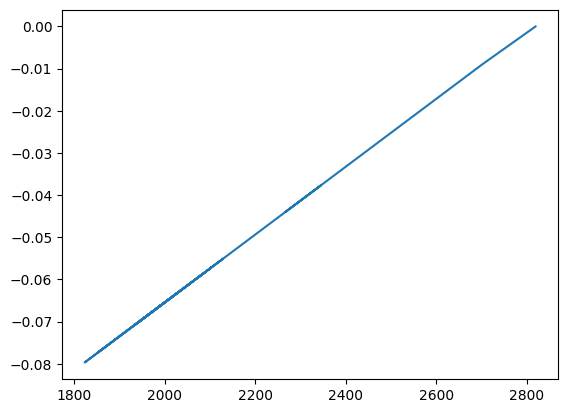

In [407]:
fig, ax = plt.subplots()
ax.plot(prices_arr, imp_loss)


## Analysis

In [342]:
ticks_df.columns

Index(['feeGrowthInside0X128', 'feeGrowthInside1X128', 'tau', 'liquidity',
       'feeGrowthOutside0X128', 'feeGrowthOutside1X128', 'price1', 'price0',
       'price', 'feeGrowthInside1'],
      dtype='str')

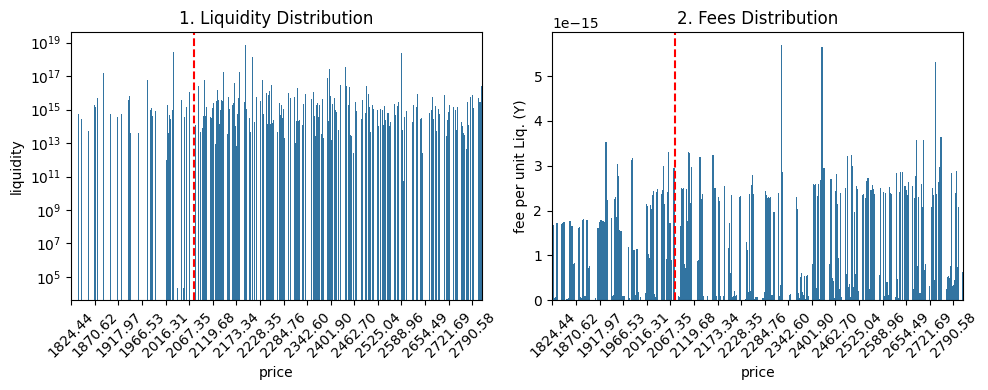

In [353]:
step = 25
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.barplot(data=ticks_df, x="price", y="liquidity", ax=ax[0])
labels_ax0 = [f"{float(item.get_text()):.02f}" for item in ax[0].get_xticklabels()] 
ax[0].set_xticks(ax[0].get_xticks()[::step]) 
ax[0].set_xticklabels(labels_ax0[::step], rotation=45)
ax[0].set_yscale('log')


sns.barplot(data=ticks_df, x="price", y="feeGrowthInside1", ax=ax[1])
labels_ax1 = [f"{float(item.get_text()):.02f}" for item in ax[1].get_xticklabels()] 
ax[1].set_xticks(ax[1].get_xticks()[::step]) 
ax[1].set_xticklabels(labels_ax1[::step], rotation=45)

prices = ticks_df['price'].unique()
prices_sorted = np.sort(ticks_df['price'].unique())
idx = np.argmin(np.abs(prices_sorted - curr_price))
ax[0].axvline(x=idx, color='r', linestyle='--', label='Current Price')
ax[1].axvline(x=idx, color='r', linestyle='--', label='Current Price')

ax[0].set_title("1. Liquidity Distribution")
ax[1].set_title("2. Fees Distribution")
ax[1].set_ylabel("fee per unit Liq. (Y)")

fig.tight_layout()
# fig.savefig("images/liquidity_fees_dist.png")
plt.show()

In [57]:
pool_data_df.columns

Index(['tick', 'active_liq', 'feeGrowthGlobal0X128', 'feeGrowthGlobal1X128',
       'fees_USD', 'volumeToken0', 'volumeToken1', 'token0Price',
       'token1Price', 'price', 'sqrt_price', 'feeGrowthGlobal0',
       'feeGrowthGlobal1', 'dfeeGrowthGlobal1X128', 'dfeeGrowthGlobal0X128'],
      dtype='str')

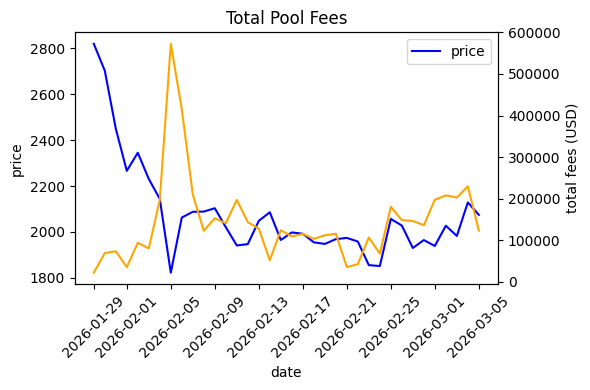

In [357]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
sns.lineplot(data=pool_data_df, x=pool_data_df.index, y="price", ax=ax, color="blue", label="price")
labels = [item.get_text() for item in ax.get_xticklabels()] 
ax.set_xticks(ax.get_xticks()) 
ax.set_xticklabels(labels, rotation=45)
ax1= ax.twinx()
sns.lineplot(data=pool_data_df, x=pool_data_df.index, y="fees_USD", ax=ax1, color='orange')
ax1.set_ylabel("total fees (USD)")
ax.set_title("Total Pool Fees")

fig.tight_layout()
fig.savefig("images/price_fees.png")
plt.show()

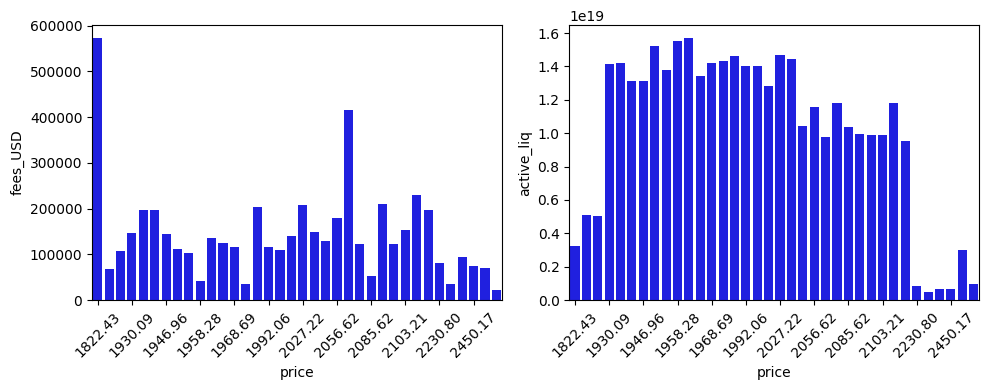

In [85]:
step = 3
fig, ax = plt.subplots(1,2,figsize=(10,4))

sns.barplot(data=pool_data_df, x="price", y="fees_USD", ax=ax[0], color='blue')
labels_ax0 = [f"{float(item.get_text()):.02f}" for item in ax[0].get_xticklabels()] 
ax[0].set_xticks(ax[0].get_xticks()[::step]) 
ax[0].set_xticklabels(labels_ax0[::step], rotation=45)

sns.barplot(data=pool_data_df, x="price", y="active_liq", ax=ax[1], color='blue')
labels_ax1 = [f"{float(item.get_text()):.02f}" for item in ax[1].get_xticklabels()] 
ax[1].set_xticks(ax[1].get_xticks()[::step]) 
ax[1].set_xticklabels(labels_ax1[::step], rotation=45)

plt.tight_layout()
plt.show()